Executive Summary:
- Average delivery times correlate with distance from Sau Paulo and population of destination city.
- Top 10 purchased item groups account for 60%-70% of the order volume across the top 5 cities
- On-time / early deliveries are largely correlated to 5 star reviews as are late deliveries to 1 star reviews.

In [26]:
#Import Libraries
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Part 1: Preliminary, What cities are placing the most delivered orders?

In [ ]:
query = """
SELECT
    c.customer_city,
    c.customer_state,
    COUNT(o.order_id) AS total_orders
FROM 'data/raw/olist_orders_dataset.csv' AS o
JOIN 'data/raw/olist_customers_dataset.csv' AS c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_city, c.customer_state
ORDER By total_orders DESC
LIMIT 10;

"""
top_cities = duckdb.query(query).df()
display(top_cities)



,customer_city,customer_state,total_orders
0,sao paulo,SP,15045
1,rio de janeiro,RJ,6601
2,belo horizonte,MG,2697
3,brasilia,DF,2071
4,curitiba,PR,1489
5,campinas,SP,1406
6,porto alegre,RS,1342
7,salvador,BA,1188
8,guarulhos,SP,1144
9,sao bernardo do campo,SP,911


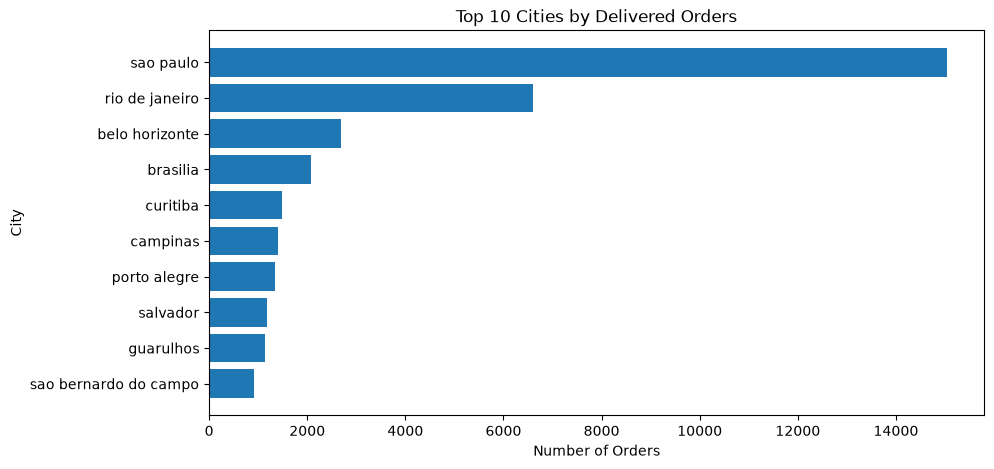

In [ ]:
# Create a horizontal bar chart
plt.figure(figsize=(10, 5))
plt.barh(top_cities['customer_city'], top_cities['total_orders'])
plt.gca().invert_yaxis()  # Put the #1 city at the very top
plt.title('Top 10 Cities by Delivered Orders')
plt.xlabel('Number of Orders')
plt.ylabel('City')
plt.show()

Most orders are in sao paulo and rio de janeiro, the most populus cities in brazil.
Sao paulo has double the orders of rio, this scales almost exactly to the population ( 12 mil vs 6.8 mil)
The difference in lifestyle (business in sao paulo, resortlike in rio) may explain the potential variance.

Could do a further analysis into the different item categories cities are ordering to find what items are in higher demand and where.

Part 2:
Delivery exploration
We want to find:
average delivery days: order_delivered_customer_date - order_purchase_timestamp
average estimated delivery days: order_estimated_delivery_date - order_purchase_timestamp
average delay days: order_delivered_customer_date - order_estimated_delivery_date
Negative means it arrived early, positive means it arrived late

,avg_actual_days,avg_estimated_days,avg_delay_days
0,-12.5,-24.4,11.9


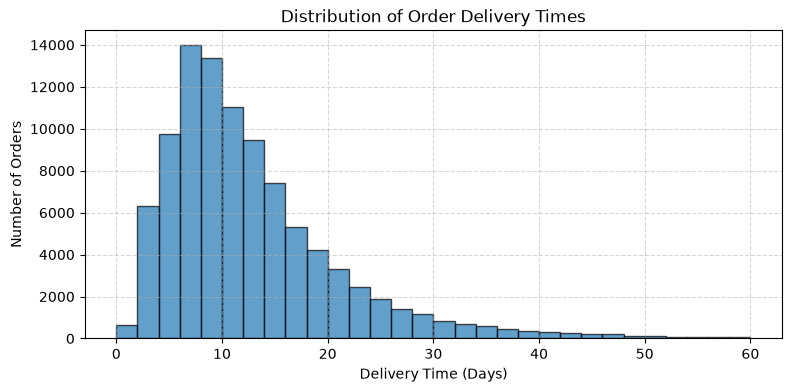

In [ ]:

query = """
SELECT
    ROUND(AVG(DATE_DIFF('day', CAST(order_delivered_customer_date AS TIMESTAMP), CAST(order_purchase_timestamp AS TIMESTAMP))),1) AS avg_actual_days,
    ROUND(AVG(DATE_DIFF('day', CAST(order_estimated_delivery_date AS TIMESTAMP), CAST(order_purchase_timestamp AS TIMESTAMP))),1) AS avg_estimated_days,
    ROUND(AVG(DATE_DIFF('day', CAST(order_delivered_customer_date AS TIMESTAMP), CAST(order_estimated_delivery_date AS TIMESTAMP))),1) AS avg_delay_days
FROM 'data/raw/olist_orders_dataset.csv'
WHERE order_status = 'delivered'
    AND order_delivered_customer_date IS NOT NULL;
"""

delivery_summary = duckdb.query(query).df()
display(delivery_summary)

# Pull the raw actual delivery days for a distribution plot
dist_query = """
SELECT 
    DATE_DIFF('day', CAST(order_purchase_timestamp AS TIMESTAMP), CAST(order_delivered_customer_date AS TIMESTAMP)) AS actual_days
FROM 'data/raw/olist_orders_dataset.csv'
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND actual_days >= 0 AND actual_days <= 60;  -- Cut off extreme outliers for cleaner plotting
"""

df_days = duckdb.query(dist_query).df()

plt.figure(figsize=(9, 4))
plt.hist(df_days['actual_days'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Order Delivery Times')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


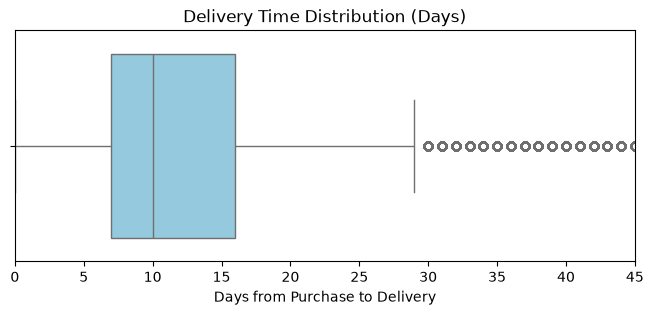

In [8]:
# Additional plot:

query = """
SELECT 
    DATE_DIFF('day', CAST(order_purchase_timestamp AS TIMESTAMP), CAST(order_delivered_customer_date AS TIMESTAMP)) AS delivery_days
FROM 'data/raw/olist_orders_dataset.csv'
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND order_delivered_customer_date >= order_purchase_timestamp;
"""

df_delivery = duckdb.query(query).df()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df_delivery['delivery_days'], color='skyblue')
plt.title('Delivery Time Distribution (Days)')
plt.xlabel('Days from Purchase to Delivery')
plt.xlim(0, 45) #Cut off extreme outliers (1.5 month plus)
plt.show()

50% of the time, you can expect a delivery between 7-16 days
Besides outliers, you can expect to recieve your delivery within the month.


Part 3: Delivery times across top 5 most ordered states

/var/folders/j5/ds_8p6x1165fchl9gpfr2z600000gn/T/ipykernel_67206/2452073985.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


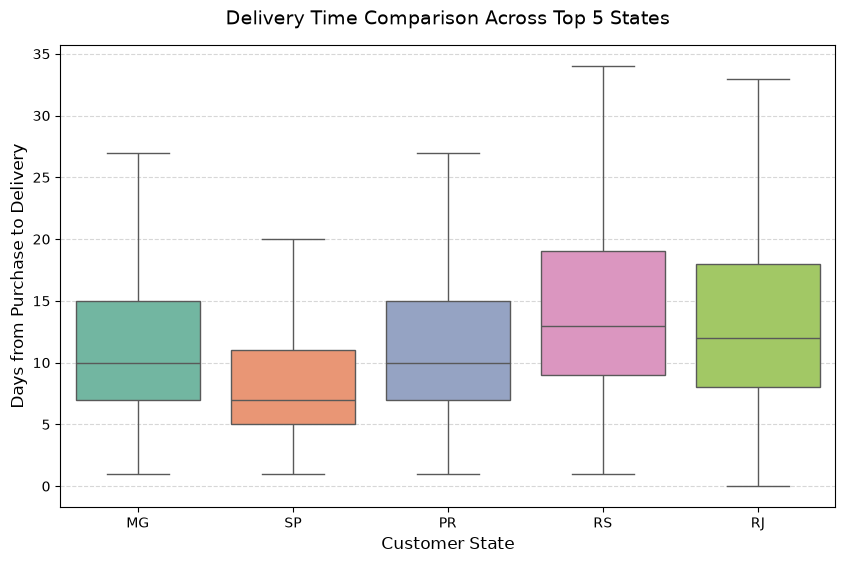

In [9]:
query = """
WITH top_states AS (
    -- Find the 5 states with the highest order volume
    SELECT c.customer_state
    FROM 'data/raw/olist_orders_dataset.csv' AS o
    JOIN 'data/raw/olist_customers_dataset.csv' AS c 
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_state
    ORDER BY COUNT(o.order_id) DESC
    LIMIT 5
)

SELECT 
    c.customer_state,
    DATE_DIFF('day', CAST(o.order_purchase_timestamp AS TIMESTAMP), CAST(o.order_delivered_customer_date AS TIMESTAMP)) AS delivery_days
FROM 'data/raw/olist_orders_dataset.csv' AS o
JOIN 'data/raw/olist_customers_dataset.csv' AS c 
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_delivered_customer_date >= o.order_purchase_timestamp
  AND c.customer_state IN (SELECT customer_state FROM top_states);
"""

df_state_delivery = duckdb.query(query).df()

plt.figure(figsize=(10, 6))

# showfliers=False hides the extreme outlier dots so the boxes remain large and easy to read.
# If you want to see the outlier dots, change showfliers to True.
sns.boxplot(
    data=df_state_delivery,
    x='customer_state',
    y='delivery_days',
    palette='Set2',
    showfliers=False
)

plt.title('Delivery Time Comparison Across Top 5 States', fontsize=14, pad=15)
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('Days from Purchase to Delivery', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Longer average shipping times correlate to higher maximum delivery time.
Preliminary observation shows that times scale off distance from SP and density of area.
This could be due to the manufacturing originating from SP and distrubuting from there.

Part 4: Product segmentation by top 5 most shipped cities

In [19]:
query = """
WITH top_cities AS (
    -- 1. Identify the top 5 cities by order count
    SELECT c.customer_city
    FROM 'data/raw/olist_orders_dataset.csv' AS o
    JOIN 'data/raw/olist_customers_dataset.csv' AS c 
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_city
    ORDER BY COUNT(DISTINCT o.order_id) DESC
    LIMIT 5
),

top_categories AS (
    -- 2. Identify the top 10 product categories across those cities
    SELECT 
        COALESCE(t.product_category_name_english, p.product_category_name) AS category_name
    FROM 'data/raw/olist_orders_dataset.csv' AS o
    JOIN 'data/raw/olist_customers_dataset.csv' AS c 
        ON o.customer_id = c.customer_id
    JOIN 'data/raw/olist_order_items_dataset.csv' AS oi 
        ON o.order_id = oi.order_id
    JOIN 'data/raw/olist_products_dataset.csv' AS p 
        ON oi.product_id = p.product_id
    LEFT JOIN 'data/raw/product_category_name_translation.csv' AS t 
        ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
      AND c.customer_city IN (SELECT customer_city FROM top_cities)
      AND p.product_category_name IS NOT NULL
    GROUP BY category_name
    ORDER BY COUNT(oi.order_item_id) DESC
    LIMIT 10
),

item_details AS (
    -- 3. Label each sold item as its category or 'Other'
    SELECT 
        c.customer_city,
        CASE 
            WHEN COALESCE(t.product_category_name_english, p.product_category_name) IN (SELECT category_name FROM top_categories)
            THEN COALESCE(t.product_category_name_english, p.product_category_name)
            ELSE 'Other'
        END AS display_category,
        oi.order_item_id
    FROM 'data/raw/olist_orders_dataset.csv' AS o
    JOIN 'data/raw/olist_customers_dataset.csv' AS c 
        ON o.customer_id = c.customer_id
    JOIN 'data/raw/olist_order_items_dataset.csv' AS oi 
        ON o.order_id = oi.order_id
    JOIN 'data/raw/olist_products_dataset.csv' AS p 
        ON oi.product_id = p.product_id
    LEFT JOIN 'data/raw/product_category_name_translation.csv' AS t 
        ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
      AND c.customer_city IN (SELECT customer_city FROM top_cities)
)

-- 4. Aggregate by city and category bucket
SELECT 
    customer_city,
    display_category,
    COUNT(order_item_id) AS items_sold
FROM item_details
GROUP BY customer_city, display_category
ORDER BY customer_city, items_sold DESC;
"""

df_city_buckets = duckdb.query(query).df()
display(df_city_buckets.head(10))

,customer_city,display_category,items_sold
0,belo horizonte,Other,1050
1,belo horizonte,bed_bath_table,348
2,belo horizonte,health_beauty,267
3,belo horizonte,computers_accessories,251
4,belo horizonte,furniture_decor,241
5,belo horizonte,housewares,234
6,belo horizonte,sports_leisure,209
7,belo horizonte,toys,141
8,belo horizonte,watches_gifts,127
9,belo horizonte,garden_tools,123


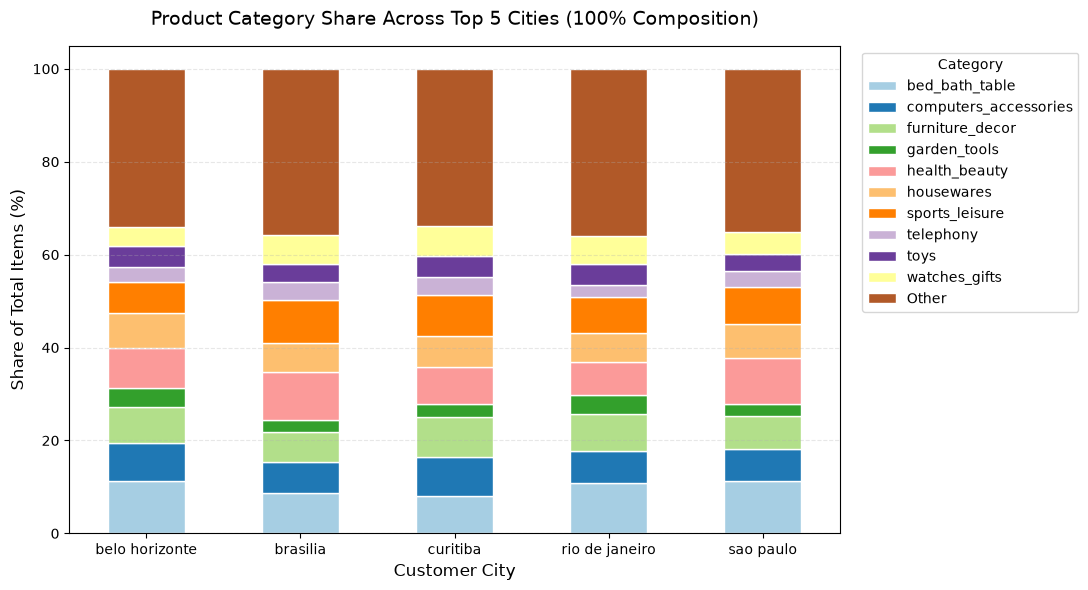

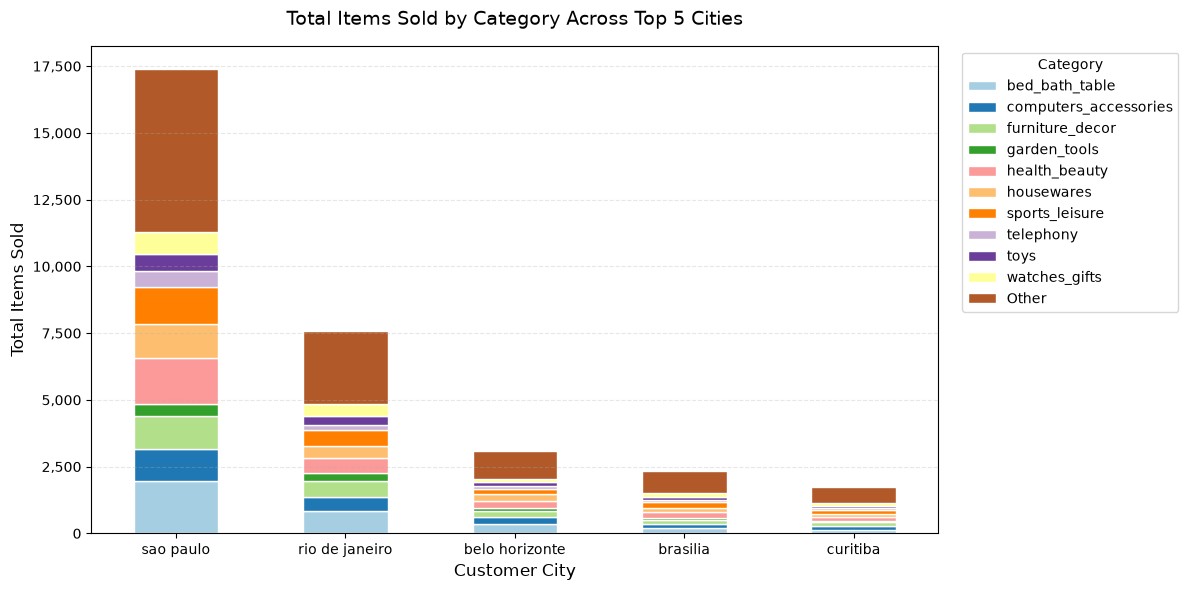

In [21]:
# 1. Pivot the data into a matrix
pivot_df = df_city_buckets.pivot_table(
    index='customer_city', 
    columns='display_category', 
    values='items_sold', 
    fill_value=0
)

# Optional: Ensure 'Other' is the last column so it sits at the top of each stacked bar
cols = [c for c in pivot_df.columns if c != 'Other'] + ['Other']
pivot_df = pivot_df[cols]

# 2. Normalize to 100% per city
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# 3. Plot
ax = pivot_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(11, 6), 
    colormap='Paired', 
    edgecolor='white'
)

plt.title('Product Category Share Across Top 5 Cities (100% Composition)', fontsize=14, pad=15)
plt.xlabel('Customer City', fontsize=12)
plt.ylabel('Share of Total Items (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 1. Ensure 'Other' sits on top of each stack for visual consistency
cols = [c for c in pivot_df.columns if c != 'Other'] + ['Other']
pivot_raw = pivot_df[cols]

# 2. Sort the cities so the highest volume city is on the left
pivot_raw['total'] = pivot_raw.sum(axis=1)
pivot_raw = pivot_raw.sort_values(by='total', ascending=False).drop(columns='total')

# 3. Plot the raw stacked bar chart
ax = pivot_raw.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Paired',
    edgecolor='white'
)

# 4. Styling and annotations
plt.title('Total Items Sold by Category Across Top 5 Cities', fontsize=14, pad=15)
plt.xlabel('Customer City', fontsize=12)
plt.ylabel('Total Items Sold', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Format y-axis numbers with commas (e.g., 10,000 instead of 10000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.tight_layout()
plt.show()

Product category percentages are quite similar across cities
Top 10 items account for 60%-70% of the order volume across the top 5 cities
Bed_bath_table, Health_beauty, furniture_decor and sports_leisure consistently makeup the core consumer basket.
Tastes are identical but volume is heavily skewed to sao paulo.
Roughly 35% of sales are driven by 'other', meaning there is a large amount of specialised goods driving sales across brazil.


Part 5: Review score vs Operational Friction (Delays)
We want to find out if the cause of bad reviews are because of delays or something else

,review_score,total_orders,avg_delivery_days,avg_delay_vs_estimated,late_pct
0,1,9380,21.3,-4.0,37.8
1,2,2938,16.6,-8.6,20.6
2,3,7942,14.2,-10.8,11.0
3,4,18943,12.3,-12.4,5.0
4,5,56810,10.6,-13.4,3.0


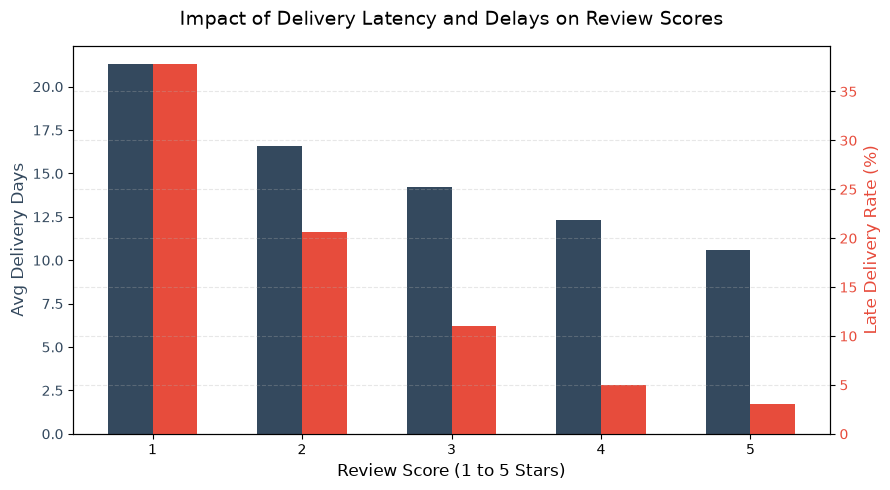

In [22]:
query_reviews = """
SELECT 
    r.review_score,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(AVG(DATE_DIFF('day', CAST(o.order_purchase_timestamp AS TIMESTAMP), CAST(o.order_delivered_customer_date AS TIMESTAMP))), 1) AS avg_delivery_days,
    ROUND(AVG(DATE_DIFF('day', CAST(o.order_estimated_delivery_date AS TIMESTAMP), CAST(o.order_delivered_customer_date AS TIMESTAMP))), 1) AS avg_delay_vs_estimated,
    ROUND(COUNT(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 END) * 100.0 / COUNT(*), 1) AS late_pct
FROM 'data/raw/olist_orders_dataset.csv' AS o
JOIN 'data/raw/olist_order_reviews_dataset.csv' AS r 
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY r.review_score
ORDER BY r.review_score ASC;
"""

df_reviews = duckdb.query(query_reviews).df()
display(df_reviews)

fig, ax1 = plt.subplots(figsize=(9, 5))

# Primary axis: Average Delivery Days
color1 = '#34495e'
ax1.bar(df_reviews['review_score'] - 0.15, df_reviews['avg_delivery_days'], width=0.3, color=color1, label='Avg Delivery Days')
ax1.set_xlabel('Review Score (1 to 5 Stars)', fontsize=12)
ax1.set_ylabel('Avg Delivery Days', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks([1, 2, 3, 4, 5])

# Secondary axis: Late Delivery %
ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.bar(df_reviews['review_score'] + 0.15, df_reviews['late_pct'], width=0.3, color=color2, label='% Late Deliveries')
ax2.set_ylabel('Late Delivery Rate (%)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Impact of Delivery Latency and Delays on Review Scores', fontsize=14, pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Additional Correlation calculation:

In [23]:
query_corr = """
SELECT 
    r.review_score,
    DATE_DIFF('day', CAST(o.order_purchase_timestamp AS TIMESTAMP), CAST(o.order_delivered_customer_date AS TIMESTAMP)) AS delivery_days,
    DATE_DIFF('day', CAST(o.order_estimated_delivery_date AS TIMESTAMP), CAST(o.order_delivered_customer_date AS TIMESTAMP)) AS delay_vs_estimated
FROM 'data/raw/olist_orders_dataset.csv' AS o
JOIN 'data/raw/olist_order_reviews_dataset.csv' AS r 
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL;
"""

df_corr = duckdb.query(query_corr).df()
# Calculate Spearman rank correlation matrix
spearman_matrix = df_corr.corr(method='spearman')
display(spearman_matrix)

# Extract specific coefficients
r_delivery = spearman_matrix.loc['review_score', 'delivery_days']
r_delay = spearman_matrix.loc['review_score', 'delay_vs_estimated']

print(f"Spearman correlation between Review Score & Actual Delivery Days: {r_delivery:.3f}")
print(f"Spearman correlation between Review Score & Delay vs Estimated: {r_delay:.3f}")

,review_score,delivery_days,delay_vs_estimated
review_score,1.000000,-0.234660,-0.176212
delivery_days,-0.234660,1.000000,0.310938
delay_vs_estimated,-0.176212,0.310938,1.000000


Spearman correlation between Review Score & Actual Delivery Days: -0.235
Spearman correlation between Review Score & Delay vs Estimated: -0.176


Global spearman ranked correlation shows only a modest relationship, this is because of the bounded non-linear relationship of review scores. Earlier deliveries can only ever get a maximum of 5.
Now to use risk penalty:

In [24]:
# Group into On-Time vs Late to see the true cliff
risk_query = """
SELECT 
    CASE 
        WHEN delay_vs_estimated > 0 THEN 'Late Delivery'
        ELSE 'On-Time / Early'
    END AS delivery_status,
    COUNT(*) AS total_orders,
    ROUND(AVG(review_score), 2) AS avg_stars,
    ROUND(COUNT(CASE WHEN review_score = 1 THEN 1 END) * 100.0 / COUNT(*), 1) AS pct_1_star,
    ROUND(COUNT(CASE WHEN review_score = 5 THEN 1 END) * 100.0 / COUNT(*), 1) AS pct_5_star
FROM df_corr
GROUP BY delivery_status;
"""

df_risk = duckdb.query(risk_query).df()
display(df_risk)

,delivery_status,total_orders,avg_stars,pct_1_star,pct_5_star
0,Late Delivery,6409,2.27,53.7,16.5
1,On-Time / Early,89944,4.29,6.6,62.3


The table shows us that on-time / early deliveries are largely correlated to 5 star reviews and the inverse, is also true. 16.5% of reviews stayed 5 stars even with a late delivery, this shows that other factors such as product quality or service may also play a role. Delivery puntualality serves as a baseline for 5 stars rather than an add-on.

Part 6: Seasonal trends and growth over time
What purchase trends are shown and when?
Is the e-commerce sales growing or slowing down?
Between Jan 2017-Aug 2018

,order_month,total_orders,total_revenue,avg_order_value
0,2017-01,750,111798.36,149.06
1,2017-02,1653,234223.40,141.70
2,2017-03,2546,359198.85,141.08
3,2017-04,2303,340669.68,147.92
4,2017-05,3546,489338.25,138.00


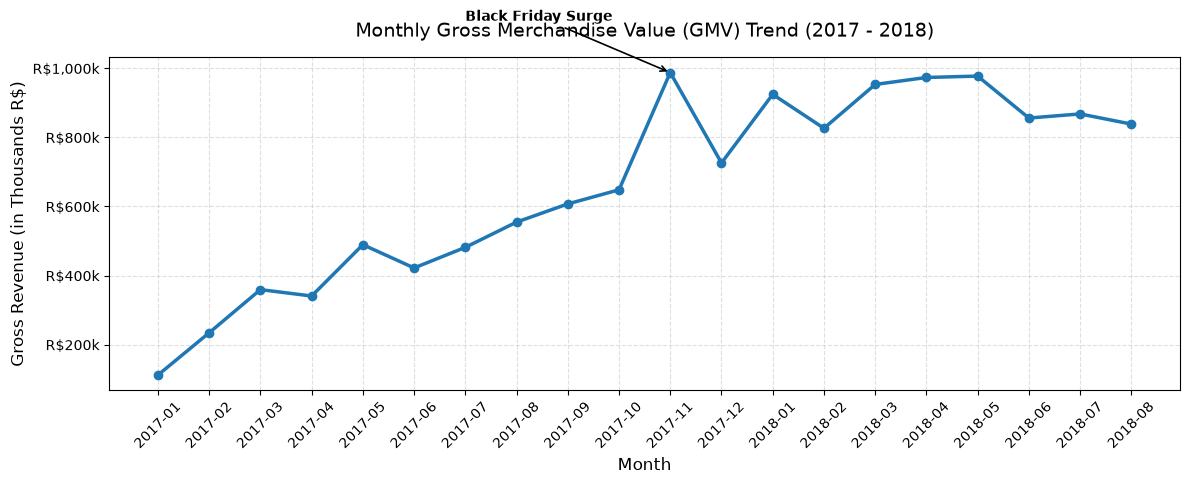

In [25]:
query_revenue = """
SELECT 
    STRFTIME(DATE_TRUNC('month', CAST(o.order_purchase_timestamp AS TIMESTAMP)), '%Y-%m') AS order_month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(SUM(oi.price) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
FROM 'data/raw/olist_orders_dataset.csv' AS o
JOIN 'data/raw/olist_order_items_dataset.csv' AS oi 
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp >= '2017-01-01'
  AND o.order_purchase_timestamp < '2018-09-01'
GROUP BY order_month
ORDER BY order_month ASC;
"""

df_revenue = duckdb.query(query_revenue).df()
display(df_revenue.head())

plt.figure(figsize=(12, 5))

# Plot revenue line
plt.plot(
    df_revenue['order_month'], 
    df_revenue['total_revenue'] / 1000.0, 
    marker='o', 
    color='#1f77b4', 
    linewidth=2.5, 
    markersize=6
)

plt.title('Monthly Gross Merchandise Value (GMV) Trend (2017 - 2018)', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Gross Revenue (in Thousands R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)

# Format y-axis with comma thousands
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R${int(x):,}k"))

# Portfolio touch: Annotate November 2017 (Black Friday spike)
if '2017-11' in df_revenue['order_month'].values:
    bf_revenue = df_revenue.loc[df_revenue['order_month'] == '2017-11', 'total_revenue'].values[0] / 1000.0
    plt.annotate(
        'Black Friday Surge',
        xy=('2017-11', bf_revenue),
        xytext=('2017-07', bf_revenue + 150),
        arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

The graph shows a steady growth of revenue over time, with a trend of plateuing by the end of august 2018.
A spike is shown on black friday in which sales increased by R$300-400k.